## HW1 - SETUP + QUESTION 1 (Load and inspect the data)

In [1]:
# =============================================================================
# HW1 - SETUP + QUESTION 1 (Load and inspect the data)
# NHAMCS Emergency Department 2015 | MGT 634
# =============================================================================
# Run this cell first. Every later step reuses the variables created here
# (df = the data, W = the survey weights), so don't restart the kernel between steps.

# ---- 0. IMPORTS --------------------------------------------------------------
import os
import sys
# Known cluster quirk: "pip install --user" packages live here and the Jupyter
# kernel doesn't always look there. Adding it is harmless if it's not needed.
sys.path.insert(0, os.path.expanduser("~/.local/lib/python3.9/site-packages"))

import numpy as np                # math on whole columns at once
import pandas as pd               # tables (DataFrames)
from IPython.display import display   # pretty tables in Jupyter

pd.set_option("display.width", 200)          # show wide tables without wrapping
pd.set_option("display.max_columns", 60)     # show up to 60 columns
pd.set_option("display.max_rows", 120)       # show up to 120 rows

# ---- 1. DATA FILE -----------------------------------------------------------
# "~" = your own home folder, so this path works for every teammate's NetID.
DATA_FILE = os.path.expanduser("~/esai_2026/data/NHAMCS/nhamcsed2015.csv")
print("Using:", DATA_FILE)

# ---- 2. LOAD -----------------------------------------------------------------
# The file is small (~21k rows), so plain pandas is the right tool here - no
# need for Dask/DuckDB/Polars (those pay off above ~10M rows).
# low_memory=False reads each column in one pass so its type is detected consistently.
df = pd.read_csv(DATA_FILE, low_memory=False)

# The homework writes names in CAPITALS (PATWT, AGE...). Make the file match.
df.columns = [c.upper() for c in df.columns]
print("Loaded. Rows:", f"{len(df):,}")          # sanity check right after loading

W = df["PATWT"].astype(float)   # survey weight: # of real U.S. visits each row represents

# =============================================================================
# QUESTION 1(a) - Number of rows and columns
# =============================================================================
print("\n" + "=" * 70 + "\nQ1(a) ROWS AND COLUMNS\n" + "=" * 70)
print(f"Rows (visits): {df.shape[0]:,}   Columns (variables): {df.shape[1]:,}")
# Unit test against the official codebook (p.115): 21,061 records
print("Matches codebook's 21,061 records?", "YES" if df.shape[0] == 21061 else "NO - CHECK")
print("Column types:", df.dtypes.astype(str).value_counts().to_dict())

Using: /home/mkk49/esai_2026/data/NHAMCS/nhamcsed2015.csv
Loaded. Rows: 21,061

Q1(a) ROWS AND COLUMNS
Rows (visits): 21,061   Columns (variables): 1,031
Matches codebook's 21,061 records? YES
Column types: {'float64': 570, 'int64': 408, 'object': 53}


## QUESTION 1(b) - Which variables have substantial missing data?

In [2]:
# =============================================================================
# QUESTION 1(b) - Which variables have substantial missing data?
# =============================================================================
print("\n" + "=" * 70 + "\nQ1(b) MISSING DATA\n" + "=" * 70)

# (i) What the assignment suggests: df.isna().sum() = count of true blanks (NaN)
na_count = df.isna().sum()
print(f"Columns with ANY true NaN: {(na_count > 0).sum()} of {df.shape[1]}")
print("Top 10 by NaN count:")
display(na_count.sort_values(ascending=False).head(10).to_frame("NaN count"))

# (ii) The catch: NCHS does NOT leave missing answers blank. It writes codes:
#      -9 = Blank, -8 = Unknown, -7 = Not applicable (question didn't apply).
#      df.isna() can't see these, so we count them ourselves.
num = df.select_dtypes(include="number")          # numeric columns only
blank_or_unknown = 100 * num.isin([-9, -8]).mean() # % of rows coded -9 or -8
print(f"\nColumns where >5% of rows are coded -9/-8 (truly missing): "
      f"{(blank_or_unknown > 5).sum()}")
print(f"Columns where >20% of rows are coded -9/-8: {(blank_or_unknown > 20).sum()}")
print("Top 25 columns by % coded missing (-9 Blank / -8 Unknown):")
display(blank_or_unknown.sort_values(ascending=False).head(25).round(1).to_frame("% missing"))

# (iii) Same breakdown for exactly the variables this homework uses
hw_vars = ["AGE", "SEX", "ETHIM", "ETHUN", "WAITTIME", "LOV", "VDAYR", "PAYTYPER",
           "TOTCHRON", "INJPOISAD", "INTENT15", "ANYIMAGE", "NUMMED", "IMMEDR",
           "PAINSCALE", "HDSTAT", "DIEDED", "DOA", "PATWT"]
hw_vars = [v for v in hw_vars if v in num.columns]
hw_missing = pd.DataFrame({
    "% true NaN":           100 * df[hw_vars].isna().mean(),
    "% -9 Blank":           100 * (df[hw_vars] == -9).mean(),
    "% -8 Unknown":         100 * (df[hw_vars] == -8).mean(),
    "% -7 Not applicable":  100 * (df[hw_vars] == -7).mean(),
}).round(1)
print("\nMissing-value codes for the homework variables:")
display(hw_missing)
# PROOF that the -9/-8 codes really are the missing values: the codebook (p.15)
# publishes the official % of missing answers. Our code counts should match it.
official = {"WAITTIME": ([-9], 15.7), "LOV": ([-9], 7.0), "PAYTYPER": ([-9, -8], 8.7),
            "ETHUN": ([-9], 24.2), "IMMEDR": ([-9, -8], 22.2)}
print("Check vs codebook p.15 official missing rates:")
for var, (codes, pct) in official.items():
    if var in df.columns:
        ours = 100 * df[var].isin(codes).mean()
        gap = abs(ours - pct)
        verdict = "MATCH" if gap < 0.1 else ("CLOSE" if gap < 1 else "DIFFERENT")
        print(f"   {var:<10} codes {codes}: ours {ours:5.1f}% | codebook {pct:5.1f}% -> {verdict}")

# ARRTIME is stored as text, so check it separately
arr_txt = df["ARRTIME"].astype(str).str.strip()
print(f"ARRTIME (text): % blank/-9 = {100 * arr_txt.isin(['-9', '', 'nan']).mean():.1f}%")

# (iv) WHY is it missing? (Class 4: MCAR vs MAR vs MNAR.) Compare missing rates
#      across groups. If they differ a lot by triage level or region, the data are
#      NOT missing completely at random - dropping those rows could bias results.
TRIAGE = {-9: "Blank", -8: "Unknown", 0: "No triage", 1: "1 Immediate", 2: "2 Emergent",
          3: "3 Urgent", 4: "4 Semi-urgent", 5: "5 Nonurgent", 7: "ED doesn't triage"}
REGION = {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"}
miss_flags = pd.DataFrame({
    "WAITTIME missing (-9)": (df["WAITTIME"] == -9),
    "LOV missing (-9)":      (df["LOV"] == -9),
    "PAYTYPER missing (-9/-8)": df["PAYTYPER"].isin([-9, -8]),
}).astype(float)
by_triage = (100 * miss_flags.groupby(df["IMMEDR"].map(TRIAGE)).mean()).round(1)
by_triage["rows"] = df["IMMEDR"].map(TRIAGE).value_counts()   # small groups = noisy rates
print("\n% missing, by triage level (unweighted):")
display(by_triage)
if "REGION" in df.columns:
    by_region = (100 * miss_flags.groupby(df["REGION"].map(REGION)).mean()).round(1)
    by_region["rows"] = df["REGION"].map(REGION).value_counts()
    print("% missing, by region (unweighted):")
    display(by_region)

# (v) Outlier check (Class 4): convert the codes to NaN, then look at the tails
#     with describe() at the 0.5% and 99.5% percentiles.
clean_preview = df[["AGE", "WAITTIME", "LOV", "NUMMED", "TOTCHRON", "PATWT"]].copy()
clean_preview = clean_preview.where(~clean_preview.isin([-9, -8, -7]))   # codes -> NaN
print("\nRanges after removing missing codes (look at min/max and the 99.5% tail):")
display(clean_preview.describe(percentiles=[0.005, 0.25, 0.5, 0.75, 0.995]).round(1))


Q1(b) MISSING DATA
Columns with ANY true NaN: 600 of 1031
Top 10 by NaN count:


,NaN count
RX29V2C4,21061
RX30V3C4,21061
RX30V1C3,21061
RX30CAT3,21061
RX30V1C4,21061
RX30V2C4,21061
RX30V2C3,21061
RX29V3C3,21061
RX29V3C2,21061
RX29V2C3,21061



Columns where >5% of rows are coded -9/-8 (truly missing): 118
Columns where >20% of rows are coded -9/-8: 56
Top 25 columns by % coded missing (-9 Blank / -8 Unknown):


,% missing
MED30,100.0
MED29,99.9
MED28,99.9
MED27,99.9
MED26,99.9
MED25,99.8
MED24,99.8
MED23,99.7
MED22,99.7
MED21,99.7



Missing-value codes for the homework variables:


...

,WAITTIME missing (-9),LOV missing (-9),PAYTYPER missing (-9/-8),rows
IMMEDR,,,,
1 Immediate,7.1,4.8,5.7,210
2 Emergent,11.7,5.3,9.2,1583
3 Urgent,9.9,4.8,7.1,6605
4 Semi-urgent,10.9,4.8,7.5,5652
5 Nonurgent,8.4,3.9,9.1,1043
Blank,45.3,34.0,25.4,488
ED doesn't triage,38.0,10.1,3.2,724
No triage,41.9,19.5,10.8,573
Unknown,21.7,9.7,11.6,4183


% missing, by region (unweighted):


,WAITTIME missing (-9),LOV missing (-9),PAYTYPER missing (-9/-8),rows
REGION,,,,
Midwest,9.8,5.1,8.3,5653
Northeast,19.7,6.4,13.5,4294
South,14.3,7.9,5.0,7023
West,19.4,8.8,10.7,4091



Ranges after removing missing codes (look at min/max and the 99.5% tail):


,AGE,WAITTIME,LOV,NUMMED,TOTCHRON,PATWT
count,21061.0,17153.0,19581.0,21061.0,20722.0,21061.0
mean,37.6,40.3,221.9,2.5,1.1,6502.2
std,24.1,75.9,295.8,2.9,1.5,5453.7
min,0.0,0.0,0.0,0.0,0.0,117.0
0.5%,0.0,0.0,14.0,0.0,0.0,231.0
25%,19.0,7.0,90.0,1.0,0.0,2797.0
50%,34.0,19.0,154.0,2.0,0.0,5232.0
75%,55.0,44.0,251.0,3.0,2.0,8226.0
99.5%,93.0,638.1,1891.3,18.0,7.0,35714.0
max,93.0,1305.0,5732.0,30.0,12.0,42002.0


## QUESTION 1(c) - What does each row represent?

In [3]:
# =============================================================================
# QUESTION 1(c) - What does each row represent?
# =============================================================================
print("\n" + "=" * 70 + "\nQ1(c) WHAT IS ONE ROW?\n" + "=" * 70)
# Codebook p.28: each record = one sampled ED VISIT (one Patient Record Form).
# A visit is uniquely identified by hospital code + patient code. Check that:
dupes = df.duplicated(subset=["HOSPCODE", "PATCODE"]).sum()
print(f"Duplicate HOSPCODE+PATCODE pairs: {dupes}  (0 = every row is a distinct visit)")
print(f"Number of hospitals (EDs) in the sample: {df['HOSPCODE'].nunique()}")
print(f"Visits sampled per hospital: median {df.groupby('HOSPCODE').size().median():.0f}, "
      f"min {df.groupby('HOSPCODE').size().min()}, max {df.groupby('HOSPCODE').size().max()}")
print(f"Each row stands for ~{W.mean():,.0f} real U.S. visits on average "
      f"(PATWT ranges {W.min():,.0f} to {W.max():,.0f})")


Q1(c) WHAT IS ONE ROW?
Duplicate HOSPCODE+PATCODE pairs: 0  (0 = every row is a distinct visit)
Number of hospitals (EDs) in the sample: 248
Visits sampled per hospital: median 94, min 3, max 163
Each row stands for ~6,502 real U.S. visits on average (PATWT ranges 117 to 42,002)


## QUESTION 2 - Weighted totals and sample design

Q2(a) UNWEIGHTED VISITS
Sampled visits in the file (each row = one visit): 21,061

Q2(b) WEIGHTED TOTAL (sum of PATWT)
Estimated U.S. ED visits in 2015: 136,943,181  (~136.9 million)
Matches codebook's 136,943,181? YES
Over 100 million, as the assignment expects? YES

How many real visits one sampled row represents (PATWT):


,PATWT
count,21061.0
mean,6502.0
std,5454.0
min,117.0
1%,298.0
25%,2797.0
50%,5232.0
75%,8226.0
99%,27224.0
max,42002.0


The 10% of rows with the largest weights account for 28.7% of all weighted visits -> weighting can move results noticeably.

Region: sample vs weighted national share:


,% of sampled rows (unweighted),% of U.S. visits (weighted)
REGION,,
Northeast,20.4,17.3
Midwest,26.8,24.2
South,33.3,37.8
West,19.4,20.7


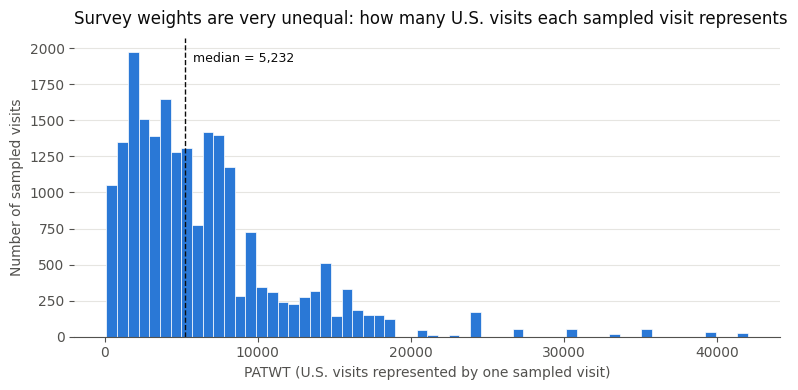

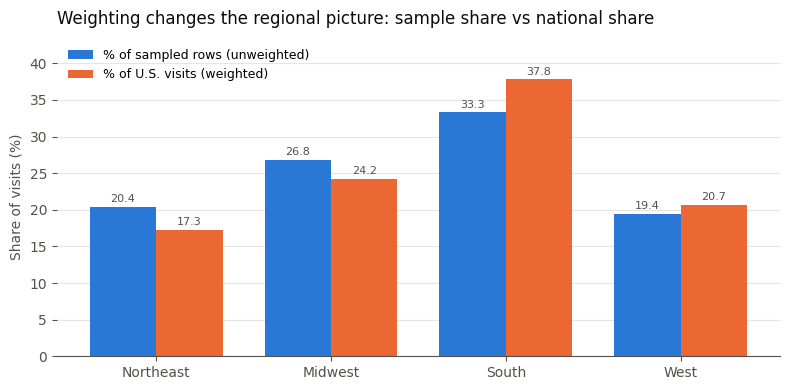

In [4]:
# =============================================================================
# QUESTION 2 - Weighted totals and sample design
# =============================================================================
# Uses df (the data) and W (the PATWT survey weights) created in the Q1 cell.

import matplotlib.pyplot as plt   # charts

# ---- Chart setup, reused by every later question -----------------------------
FIG_DIR = os.path.expanduser("~/hw1_output/figures")   # charts saved here for the write-up
os.makedirs(FIG_DIR, exist_ok=True)                     # create the folder if missing
BLUE, ORANGE = "#2a78d6", "#eb6834"      # series colours (colour-blind-safe pair)
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e6e5e1"   # text, axis labels, gridlines

def style_axes(ax, title, xlabel="", ylabel=""):
    """Class 5 principles: labelled units, light gridlines, no clutter (no box)."""
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=10)
    ax.set_xlabel(xlabel, color=INK_SOFT)
    ax.set_ylabel(ylabel, color=INK_SOFT)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(INK_SOFT)
    ax.tick_params(colors=INK_SOFT)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)                 # gridlines behind the bars

def save_fig(fig, name):
    """Save a high-resolution PNG for the write-up/slides, then show it."""
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=200)
    plt.show()

# ---- (a) Unweighted count of visits -----------------------------------------
print("=" * 70 + "\nQ2(a) UNWEIGHTED VISITS\n" + "=" * 70)
print(f"Sampled visits in the file (each row = one visit): {len(df):,}")

# ---- (b) Weighted total = estimated number of U.S. ED visits in 2015 --------
print("\n" + "=" * 70 + "\nQ2(b) WEIGHTED TOTAL (sum of PATWT)\n" + "=" * 70)
total_visits = W.sum()
print(f"Estimated U.S. ED visits in 2015: {total_visits:,.0f}  (~{total_visits/1e6:.1f} million)")
# Unit test against the codebook (p.28 and p.115): 136,943,181 visits
print("Matches codebook's 136,943,181?", "YES" if round(total_visits) == 136943181 else "NO")
print(f"Over 100 million, as the assignment expects? {'YES' if total_visits > 100e6 else 'NO'}")

# ---- Sample design: how unequal are the weights? ----------------------------
# NHAMCS is a multi-stage sample (areas -> hospitals -> EDs -> visits), so some
# visits stand for many more real visits than others.
print("\nHow many real visits one sampled row represents (PATWT):")
display(W.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(0).to_frame("PATWT"))
top10 = W.sort_values(ascending=False).head(int(len(W) * 0.10)).sum() / total_visits
print(f"The 10% of rows with the largest weights account for {100*top10:.1f}% of all "
      f"weighted visits -> weighting can move results noticeably.")

# Where weighting matters most: sample share vs national (weighted) share, by region
REGION = {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"}
region_share = pd.DataFrame({
    "% of sampled rows (unweighted)": 100 * df["REGION"].value_counts(normalize=True),
    "% of U.S. visits (weighted)": 100 * W.groupby(df["REGION"]).sum() / total_visits,
}).rename(index=REGION).round(1)
print("\nRegion: sample vs weighted national share:")
display(region_share)

# ---- Chart 1: distribution of the weights -----------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(W, bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(W.median(), color=INK, linestyle="--", linewidth=1)
ax.text(W.median(), ax.get_ylim()[1] * 0.92, f"  median = {W.median():,.0f}",
        color=INK, fontsize=9)
style_axes(ax, "Survey weights are very unequal: how many U.S. visits each sampled visit represents",
           xlabel="PATWT (U.S. visits represented by one sampled visit)",
           ylabel="Number of sampled visits")
save_fig(fig, "q2_weight_distribution")

# ---- Chart 2: unweighted vs weighted share by region -------------------------
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(region_share))       # one position per region
bw = 0.38                              # bar width
b1 = ax.bar(x - bw/2, region_share.iloc[:, 0], bw, color=BLUE, label=region_share.columns[0])
b2 = ax.bar(x + bw/2, region_share.iloc[:, 1], bw, color=ORANGE, label=region_share.columns[1])
ax.bar_label(b1, fmt="%.1f", padding=2, fontsize=8, color=INK_SOFT)   # direct value labels
ax.bar_label(b2, fmt="%.1f", padding=2, fontsize=8, color=INK_SOFT)
ax.set_xticks(x)
ax.set_xticklabels(region_share.index)
ax.set_ylim(0, region_share.values.max() * 1.15)   # bars start at zero (Class 5 rule)
ax.legend(frameon=False, fontsize=9)
style_axes(ax, "Weighting changes the regional picture: sample share vs national share",
           ylabel="Share of visits (%)")
save_fig(fig, "q2_region_unweighted_vs_weighted")

## QUESTION 3 - Basic descriptive statistics (unweighted AND weighted)

Weighted mean/median functions pass their unit tests.
Winsorizing caps: WAITTIME at 638 min, LOV at 1891 min (86 and 98 visits capped)

Q3 (a)(c)(d) AGE, WAIT TIME, LENGTH OF VISIT
                              unweighted  weighted  rows used  wtd - unwtd
statistic                                                                 
(a) Age, mean (yrs)                 37.6      37.0      21061         -0.5
(a) Age, median (yrs)               34.0      34.0      21061          0.0
(c) Wait, MEDIAN (min)              19.0      18.0      17153         -1.0
    Wait, mean raw (min)            40.3      39.3      17153         -1.0
    Wait, mean winsor. (min)        39.5      38.7      17153         -0.9
(d) LOV, MEAN raw (min)            221.9     213.7      19581         -8.2
(d) LOV, MEAN winsor. (min)        216.5     209.8      19581         -6.7
    LOV, median (min)              154.0     154.0      19581          0.0
(LOV = length of visit; winsor. = extreme values capped at the 99.5th

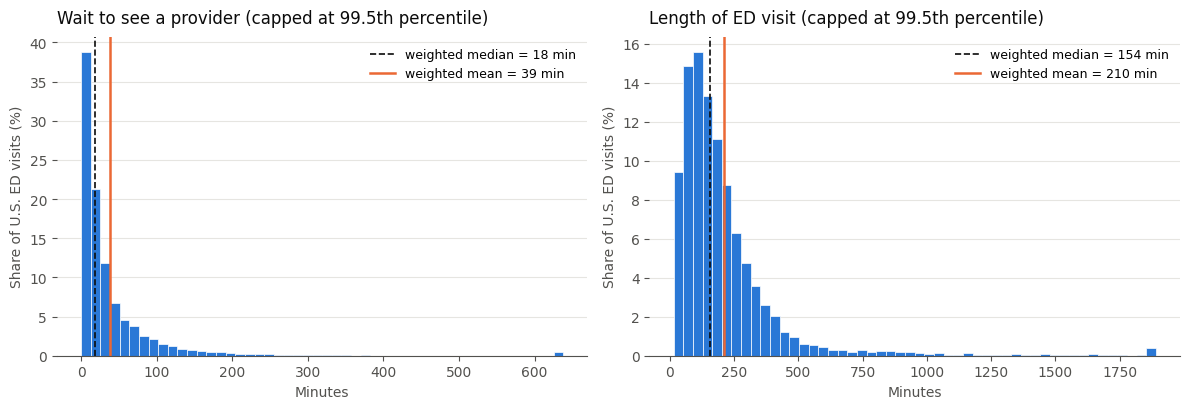

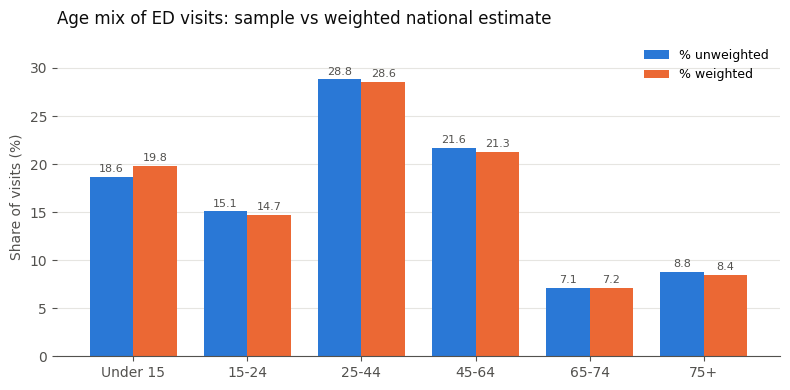

In [5]:
# =============================================================================
# QUESTION 3 - Basic descriptive statistics (unweighted AND weighted)
# =============================================================================

# ---- Helper functions, reused by later questions ----------------------------
MISSING_CODES = [-9, -8, -7]   # Blank / Unknown / Not applicable (see Q1)

def valid(col):
    """Return a column as numbers, with the missing codes turned into NaN
    so they are left out of every statistic."""
    s = pd.to_numeric(df[col], errors="coerce")
    return s.where(~s.isin(MISSING_CODES))

def w_mean(x, w=W):
    """Weighted mean, skipping missing values."""
    keep = x.notna()
    return np.average(x[keep], weights=w[keep])

def w_median(x, w=W):
    """Weighted median: sort the values, add up their weights, and take the
    value where the running total first reaches half of all the weight."""
    keep = x.notna()
    v, wt = x[keep].to_numpy(float), w[keep].to_numpy(float)
    order = np.argsort(v, kind="stable")
    v, wt = v[order], wt[order]
    running = np.cumsum(wt)
    return v[np.searchsorted(running, 0.5 * running[-1])]

def winsorize(x, lower=0.005, upper=0.995):
    """Class 4 method: cap extreme values at the 0.5th / 99.5th percentiles
    instead of deleting them."""
    lo, hi = x.quantile([lower, upper])
    return x.clip(lower=lo, upper=hi)

def share_table(codes, labels, w=W):
    """One row per category: sample rows, % unweighted, weighted visits, % weighted."""
    t = pd.DataFrame({
        "sample rows": codes.value_counts(),
        "% unweighted": 100 * codes.value_counts(normalize=True),
        "weighted visits (M)": w.groupby(codes).sum() / 1e6,
        "% weighted": 100 * w.groupby(codes).sum() / w[codes.notna()].sum(),
    })
    t.index = [labels.get(i, i) for i in t.index]
    return t.round(2)

def show(table):
    """Print a table as compact plain text (no wrapped labels, easy to screenshot)."""
    print(table.to_string())

def grouped_bars(table, title, ylabel, name):
    """Two-series bar chart (unweighted vs weighted), bars start at zero, values labelled."""
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(table))
    bw = 0.38
    for i, (col, colour) in enumerate(zip(table.columns[:2], [BLUE, ORANGE])):
        bars = ax.bar(x + (i - 0.5) * bw, table[col], bw, color=colour, label=col)
        ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8, color=INK_SOFT)
    ax.set_xticks(x)
    ax.set_xticklabels(table.index)
    ax.set_ylim(0, table.iloc[:, :2].values.max() * 1.15)
    ax.legend(frameon=False, fontsize=9)
    style_axes(ax, title, ylabel=ylabel)
    save_fig(fig, name)

# Unit tests (Class 2: check functions on data where we know the right answer)
t_vals = pd.Series([1.0, 2.0, 3.0])
assert w_median(t_vals, pd.Series([1.0, 1.0, 1.0])) == 2.0    # equal weights = normal median
assert w_median(t_vals, pd.Series([1.0, 1.0, 10.0])) == 3.0   # heavy weight on 3 pulls median to 3
assert abs(w_mean(t_vals, pd.Series([1.0, 1.0, 10.0])) - 33 / 12) < 1e-12
print("Weighted mean/median functions pass their unit tests.")

# ---- Clean the three numeric variables --------------------------------------
age = valid("AGE")         # 0-93; 93 means "93 or older" (top-coded for privacy)
wait = valid("WAITTIME")   # drops -9 Blank and -7 "not seen by a provider"
lov = valid("LOV")         # drops -9 Blank
wait_win = winsorize(wait) # capped at 99.5th percentile (max raw value is ~22 hours)
lov_win = winsorize(lov)   # capped at 99.5th percentile (max raw value is ~95 hours)
print(f"Winsorizing caps: WAITTIME at {wait.quantile(0.995):.0f} min, "
      f"LOV at {lov.quantile(0.995):.0f} min "
      f"({(wait > wait.quantile(0.995)).sum()} and {(lov > lov.quantile(0.995)).sum()} visits capped)")

# ---- (a) (c) (d) Age, waiting time, length of visit --------------------------
print("\n" + "=" * 70 + "\nQ3 (a)(c)(d) AGE, WAIT TIME, LENGTH OF VISIT\n" + "=" * 70)
rows = [  # (short label, data, "mean" or "median")
    ("(a) Age, mean (yrs)",            age,      "mean"),
    ("(a) Age, median (yrs)",          age,      "median"),
    ("(c) Wait, MEDIAN (min)",         wait,     "median"),
    ("    Wait, mean raw (min)",       wait,     "mean"),
    ("    Wait, mean winsor. (min)",   wait_win, "mean"),
    ("(d) LOV, MEAN raw (min)",        lov,      "mean"),
    ("(d) LOV, MEAN winsor. (min)",    lov_win,  "mean"),
    ("    LOV, median (min)",          lov,      "median"),
]
stats = []
for label, x, kind in rows:
    stats.append({
        "statistic": label,
        "unweighted": x.median() if kind == "median" else x.mean(),
        "weighted": w_median(x) if kind == "median" else w_mean(x),
        "rows used": int(x.notna().sum()),
    })
q3_table = pd.DataFrame(stats).set_index("statistic")
q3_table["wtd - unwtd"] = q3_table["weighted"] - q3_table["unweighted"]
show(q3_table.round(1))
print("(LOV = length of visit; winsor. = extreme values capped at the 99.5th percentile)")
print(f"Weighted mean length of visit = {w_mean(lov)/60:.1f} hours (raw) / "
      f"{w_mean(lov_win)/60:.1f} hours (winsorized); median = {w_median(lov)/60:.1f} hours")

# ---- (b) Sex and ethnicity ---------------------------------------------------
print("\n" + "=" * 70 + "\nQ3 (b) SEX AND ETHNICITY\n" + "=" * 70)
sex_table = share_table(df["SEX"], {1: "Female", 2: "Male"})
eth_table = share_table(df["ETHIM"], {1: "Hispanic or Latino", 2: "Not Hispanic or Latino"})
print("By sex:")
show(sex_table)
print("\nBy ethnicity (ETHIM = imputed; the unimputed ETHUN is 24% blank, see Q1):")
show(eth_table)
# Unit tests against the codebook (p.115)
print("\nWeighted % female matches codebook 55.436%?",
      "YES" if abs(sex_table.loc["Female", "% weighted"] - 55.436) < 0.01 else "NO")
print("Weighted % Hispanic matches codebook 16.493%?",
      "YES" if abs(eth_table.loc["Hispanic or Latino", "% weighted"] - 16.493) < 0.01 else "NO")

# ---- How weighting changes the picture: age groups ---------------------------
AGE_GROUPS = {1: "Under 15", 2: "15-24", 3: "25-44", 4: "45-64", 5: "65-74", 6: "75+"}
age_table = share_table(df["AGER"], AGE_GROUPS)
print("\nAge groups, unweighted vs weighted:")
show(age_table)

# ---- Chart 1: distributions of wait time and length of visit ----------------
# Weighted histograms, so the y-axis is the share of all U.S. ED visits.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, x, name in [(axes[0], wait_win, "Wait to see a provider"),
                    (axes[1], lov_win, "Length of ED visit")]:
    keep = x.notna()
    ax.hist(x[keep], bins=50, weights=100 * W[keep] / W[keep].sum(),
            color=BLUE, edgecolor="white", linewidth=0.5)
    med, mean = w_median(x), w_mean(x)
    ax.axvline(med, color=INK, linestyle="--", linewidth=1.2,
               label=f"weighted median = {med:.0f} min")
    ax.axvline(mean, color=ORANGE, linewidth=1.8,
               label=f"weighted mean = {mean:.0f} min")
    ax.legend(frameon=False, fontsize=9)
    style_axes(ax, f"{name} (capped at 99.5th percentile)",
               xlabel="Minutes", ylabel="Share of U.S. ED visits (%)")
save_fig(fig, "q3_wait_and_length_of_visit")

# ---- Chart 2: age groups, unweighted vs weighted ----------------------------
grouped_bars(age_table[["% unweighted", "% weighted"]],
             "Age mix of ED visits: sample vs weighted national estimate",
             "Share of visits (%)", "q3_age_groups_unweighted_vs_weighted")

## QUESTION 4 - Demand patterns by time (day of week, arrival hour)

Visits with a usable arrival time: 20,779 of 21,061 (1.3% blank/invalid, dropped from the hour analysis)
Number of each weekday in 2015: {'Sun': 52, 'Mon': 52, 'Tue': 52, 'Wed': 52, 'Thu': 53, 'Fri': 52, 'Sat': 52}

Q4(a) VISITS BY DAY OF WEEK (weighted)
     total visits (M)  % of visits  avg visits per day (000s)
Sun             18.00        13.14                     346.12
Mon             22.45        16.40                     431.79
Tue             20.57        15.02                     395.54
Wed             19.72        14.40                     379.30
Thu             18.74        13.69                     353.65
Fri             18.78        13.72                     361.23
Sat             18.67        13.64                     359.08

Q4(a) VISITS BY ARRIVAL HOUR (weighted)
      total visits (M)  % of visits  avg visits per day in this hour (000s)
hour                                                                       
0                 2.97         2.20                     

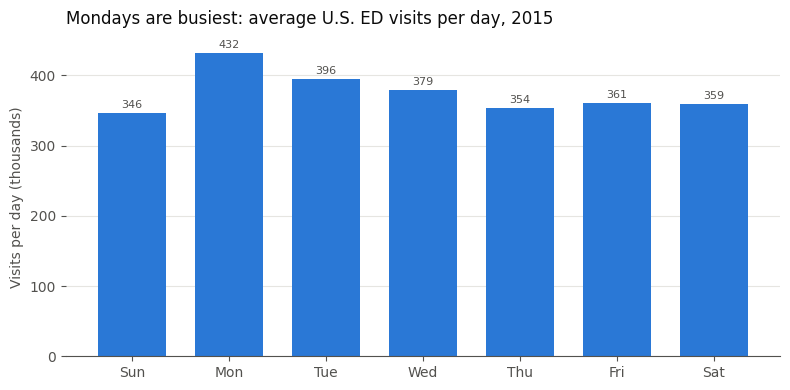

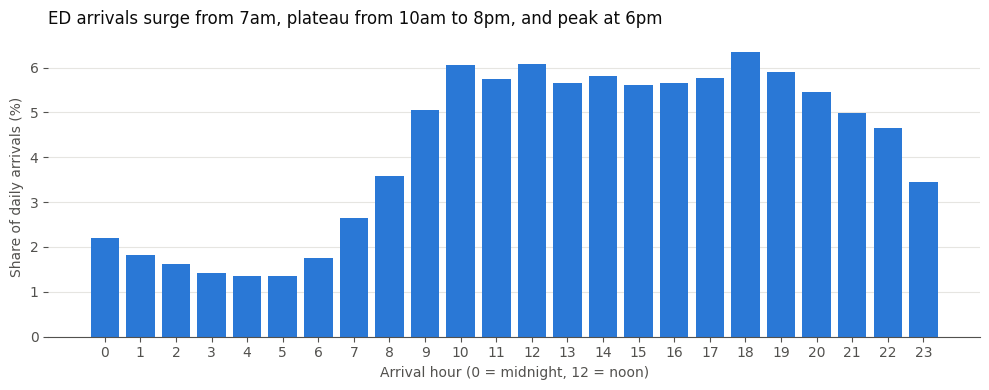

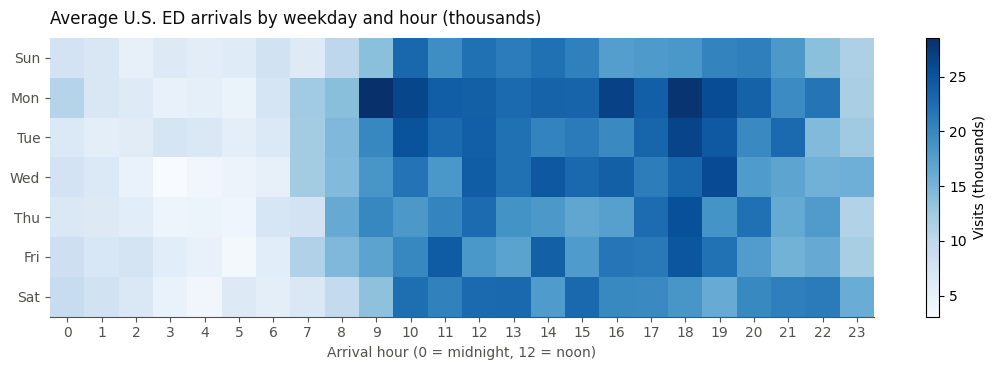

In [6]:
# =============================================================================
# QUESTION 4 - Demand patterns by time (day of week, arrival hour)
# =============================================================================

DAYS = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}

# ---- Clean arrival time ------------------------------------------------------
# ARRTIME is military time (e.g. 930 = 9:30am, 1745 = 5:45pm); -9 = blank.
# Hour of arrival = ARRTIME // 100 (drop the last two digits = minutes).
arr = pd.to_numeric(df["ARRTIME"], errors="coerce")
real_time = arr.between(0, 2359) & ((arr % 100) < 60)     # a real clock time
hour = (arr // 100).where(real_time)                      # 0 = midnight-12:59am ... 23 = 11pm
day = df["VDAYR"]                                         # 1 = Sunday ... 7 = Saturday
print(f"Visits with a usable arrival time: {real_time.sum():,} of {len(df):,} "
      f"({100 * (~real_time).mean():.1f}% blank/invalid, dropped from the hour analysis)")

# How many of each weekday 2015 had (2015 started on a Thursday -> 53 Thursdays)
days_2015 = pd.date_range("2015-01-01", "2015-12-31")
n_weekday = pd.Series((days_2015.dayofweek + 1) % 7 + 1).value_counts().sort_index()  # 1=Sun..7=Sat
print("Number of each weekday in 2015:", {DAYS[d]: int(n) for d, n in n_weekday.items()})

# ---- (a) Weighted visits by day of week -------------------------------------
print("\n" + "=" * 70 + "\nQ4(a) VISITS BY DAY OF WEEK (weighted)\n" + "=" * 70)
by_day = pd.DataFrame({
    "total visits (M)": W.groupby(day).sum() / 1e6,
    "% of visits": 100 * W.groupby(day).sum() / W.sum(),
    "avg visits per day (000s)": W.groupby(day).sum() / n_weekday / 1e3,
})
by_day.index = [DAYS[d] for d in by_day.index]
show(by_day.round(2))

# ---- (a) Weighted visits by arrival hour ------------------------------------
print("\n" + "=" * 70 + "\nQ4(a) VISITS BY ARRIVAL HOUR (weighted)\n" + "=" * 70)
by_hour = pd.DataFrame({
    "total visits (M)": W.groupby(hour).sum() / 1e6,
    "% of visits": 100 * W.groupby(hour).sum() / W[real_time].sum(),
    "avg visits per day in this hour (000s)": W.groupby(hour).sum() / 365 / 1e3,
})
by_hour.index = by_hour.index.astype(int)
by_hour.index.name = "hour"
show(by_hour.round(2))

# ---- (b) Busiest days and times ----------------------------------------------
print("\n" + "=" * 70 + "\nQ4(b) BUSIEST DAYS AND TIMES\n" + "=" * 70)
per_day = by_day["avg visits per day (000s)"]
print(f"Busiest day: {per_day.idxmax()} ({per_day.max():.0f}k visits/day); "
      f"quietest: {per_day.idxmin()} ({per_day.min():.0f}k/day); "
      f"gap = {100 * (per_day.max() / per_day.min() - 1):.1f}%")
pct_hour = by_hour["% of visits"]
top3 = pct_hour.sort_values(ascending=False).head(3)
print("Busiest arrival hours:", ", ".join(f"{h}:00-{h}:59 ({p:.1f}%)" for h, p in top3.items()))
print(f"Quietest hour: {pct_hour.idxmin()}:00-{pct_hour.idxmin()}:59 ({pct_hour.min():.1f}%); "
      f"the peak hour gets {pct_hour.max() / pct_hour.min():.1f}x as many arrivals")
print(f"Share arriving 10am-10pm: {pct_hour.loc[10:21].sum():.1f}% | "
      f"overnight midnight-7am: {pct_hour.loc[0:6].sum():.1f}%")

# Day x hour grid: average visits in that hour on that weekday (thousands)
grid = (W.groupby([day, hour]).sum().unstack()
        .div(n_weekday, axis=0) / 1e3)
grid.index = [DAYS[d] for d in grid.index]
grid.columns = grid.columns.astype(int)
peak = grid.stack().idxmax()
print(f"Single busiest slot: {peak[0]} {peak[1]}:00-{peak[1]}:59 "
      f"({grid.stack().max():.1f}k visits on average)")

# ---- Chart 1: average visits per day, by weekday (calendar order) -----------
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(per_day.index, per_day.values, color=BLUE, width=0.7)
ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8, color=INK_SOFT)
style_axes(ax, "Mondays are busiest: average U.S. ED visits per day, 2015",
           ylabel="Visits per day (thousands)")
save_fig(fig, "q4_visits_by_weekday")

# ---- Chart 2: arrivals by hour of day ----------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour.index, pct_hour.values, color=BLUE, width=0.8)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h}" for h in range(24)])
style_axes(ax, "ED arrivals surge from 7am, plateau from 10am to 8pm, and peak at 6pm",
           xlabel="Arrival hour (0 = midnight, 12 = noon)", ylabel="Share of daily arrivals (%)")
save_fig(fig, "q4_arrivals_by_hour")

# ---- Chart 3: day x hour heatmap (Class 5: heatmaps for 2-D patterns) -------
fig, ax = plt.subplots(figsize=(11, 3.8))
img = ax.imshow(grid.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(24))
ax.set_xticklabels(grid.columns)
ax.set_yticks(range(len(grid.index)))
ax.set_yticklabels(grid.index)
style_axes(ax, "Average U.S. ED arrivals by weekday and hour (thousands)",
           xlabel="Arrival hour (0 = midnight, 12 = noon)")
ax.grid(False)
fig.colorbar(img, ax=ax, label="Visits (thousands)")
save_fig(fig, "q4_weekday_hour_heatmap")

## QUESTION 5 - Payer mix (PAYTYPER = primary expected source of payment)

Q5(a) ALL VISITS BY PRIMARY EXPECTED PAYER
                           sample rows  % unweighted  weighted visits (M)  % weighted
All payment sources blank          402          1.91                 3.38        2.47
Unknown                           1436          6.82                11.36        8.30
Private insurance                 6039         28.67                37.76       27.57
Medicare                          3811         18.10                24.30       17.74
Medicaid/CHIP                     6781         32.20                42.66       31.15
Workers' comp                      154          0.73                 0.96        0.70
Self-pay                          1890          8.97                12.37        9.03
No charge/charity                  119          0.57                 1.14        0.83
Other                              429          2.04                 3.02        2.21

Check vs codebook p.116 (weighted %):
   Private insurance  ours  27.57 | codebook 27.573 -> MAT

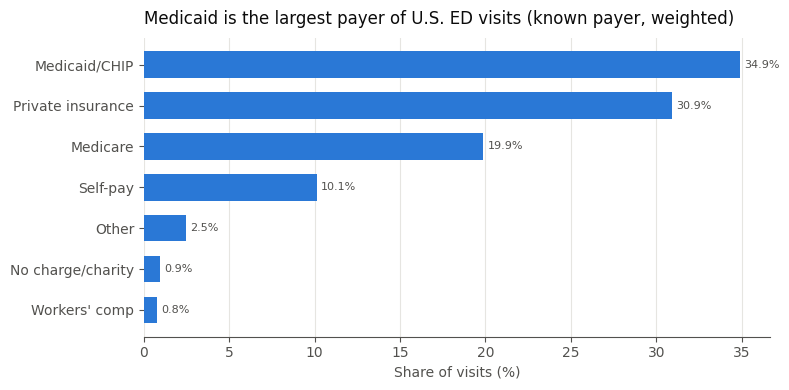

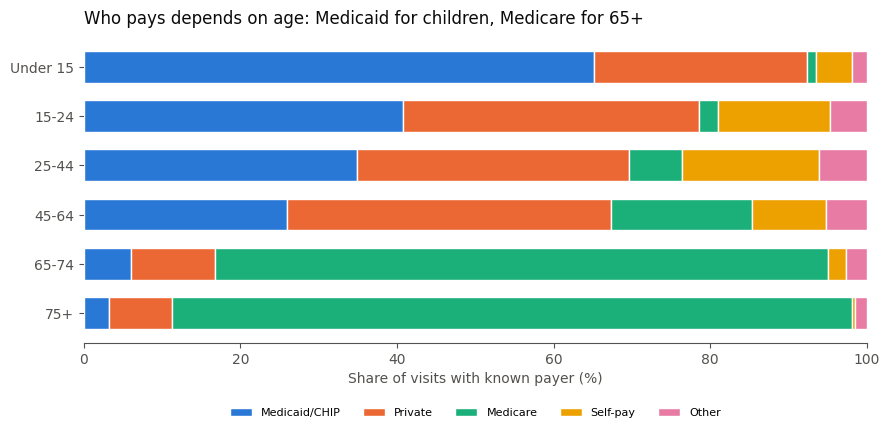

In [7]:
# =============================================================================
# QUESTION 5 - Payer mix (PAYTYPER = primary expected source of payment)
# =============================================================================
# PAYTYPER is NCHS's recode: if a visit lists several payers, one "primary"
# payer is picked by a fixed hierarchy (codebook p.116), so each visit counts once.
PAY_LABELS = {-9: "All payment sources blank", -8: "Unknown", 1: "Private insurance",
              2: "Medicare", 3: "Medicaid/CHIP", 4: "Workers' comp", 5: "Self-pay",
              6: "No charge/charity", 7: "Other"}
pay = pd.to_numeric(df["PAYTYPER"], errors="coerce")

# ---- (a) Weighted share of visits by payment type (all codes shown) ---------
print("=" * 70 + "\nQ5(a) ALL VISITS BY PRIMARY EXPECTED PAYER\n" + "=" * 70)
pay_all = share_table(pay, PAY_LABELS)
show(pay_all)

# Unit test against the codebook table (p.116, weighted %)
official = {"Private insurance": 27.573, "Medicare": 17.742, "Medicaid/CHIP": 31.152,
            "Self-pay": 9.033, "Unknown": 8.296}
print("\nCheck vs codebook p.116 (weighted %):")
for name, pct in official.items():
    ours = pay_all.loc[name, "% weighted"]
    print(f"   {name:<18} ours {ours:6.2f} | codebook {pct:6.3f} -> "
          f"{'MATCH' if abs(ours - pct) < 0.01 else 'DIFFERENT'}")

# ---- (b) The four main payers: share of all visits vs share of KNOWN payer ---
print("\n" + "=" * 70 + "\nQ5(b) MEDICARE vs MEDICAID vs PRIVATE vs SELF-PAY\n" + "=" * 70)
known = pay > 0                                   # drops -9 blank and -8 unknown
print(f"Visits with a known payer: {100 * W[known].sum() / W.sum():.1f}% (weighted)")
pay_known = share_table(pay.where(known), PAY_LABELS)
main4 = ["Medicaid/CHIP", "Private insurance", "Medicare", "Self-pay"]
compare = pd.DataFrame({
    "% of ALL visits": pay_all.loc[main4, "% weighted"],
    "% of visits with KNOWN payer": pay_known.loc[main4, "% weighted"],
    "weighted visits (M)": pay_all.loc[main4, "weighted visits (M)"],
})
show(compare.round(2))
public = pay_known.loc[["Medicaid/CHIP", "Medicare"], "% weighted"].sum()
print(f"\nPublic payers (Medicaid + Medicare): {public:.1f}% of known-payer visits")
print(f"Uncompensated-risk payers (Self-pay + No charge): "
      f"{pay_known.loc[['Self-pay', 'No charge/charity'], '% weighted'].sum():.1f}%")

# Visits can list MORE than one payer (e.g. Medicare + Medicaid "dual eligibles").
# Share of visits where each payer is listed at all (not just as primary):
any_payer = pd.Series({
    "Private insurance": W[df["PAYPRIV"] == 1].sum(),
    "Medicare": W[df["PAYMCARE"] == 1].sum(),
    "Medicaid/CHIP": W[df["PAYMCAID"] == 1].sum(),
    "Self-pay": W[df["PAYSELF"] == 1].sum(),
}) / W.sum() * 100
print("\n% of all visits where each payer is listed at all (a visit can list several):")
show(any_payer.round(2).to_frame("% of visits"))

# ---- Payer mix by age group (the main driver of payer mix) ------------------
PAY_GROUP = {1: "Private", 2: "Medicare", 3: "Medicaid/CHIP", 5: "Self-pay",
             4: "Other", 6: "Other", 7: "Other"}
pay_grp = pay.map(PAY_GROUP)                      # NaN for -9/-8 (unknown payer)
mix_by_age = (W.groupby([df["AGER"], pay_grp]).sum().unstack()
              .pipe(lambda t: 100 * t.div(t.sum(axis=1), axis=0)))
mix_by_age.index = [AGE_GROUPS[a] for a in mix_by_age.index]
mix_by_age = mix_by_age[["Medicaid/CHIP", "Private", "Medicare", "Self-pay", "Other"]]
print("\nPayer mix by age group (weighted %, known payer only, rows sum to 100):")
show(mix_by_age.round(1))

# ---- Chart 1: payer mix, ordered by size (Class 5: order bars by value) -----
chart = pay_known["% weighted"].sort_values()     # smallest at bottom, largest on top
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(chart.index, chart.values, color=BLUE, height=0.65)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8, color=INK_SOFT)
style_axes(ax, "Medicaid is the largest payer of U.S. ED visits (known payer, weighted)",
           xlabel="Share of visits (%)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID, linewidth=0.8)
save_fig(fig, "q5_payer_mix")

# ---- Chart 2: payer mix by age group (100% stacked bars) --------------------
colours = [BLUE, ORANGE, "#1baf7a", "#eda100", "#e87ba4"]   # fixed colour per payer
fig, ax = plt.subplots(figsize=(9, 4.5))
left = np.zeros(len(mix_by_age))
for col, colour in zip(mix_by_age.columns, colours):
    ax.barh(mix_by_age.index, mix_by_age[col], left=left, color=colour, label=col,
            height=0.65, edgecolor="white", linewidth=1)
    left += mix_by_age[col].values
ax.invert_yaxis()                                 # youngest at the top
ax.set_xlim(0, 100)
ax.legend(frameon=False, fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
style_axes(ax, "Who pays depends on age: Medicaid for children, Medicare for 65+",
           xlabel="Share of visits with known payer (%)")
ax.grid(False)
save_fig(fig, "q5_payer_mix_by_age")

## QUESTION 6 - Chronic conditions

Chronic-condition section answered: 20,722 of 21,061 visits (1.6% blank, excluded from this question)
TOTCHRON equals the number of ticked boxes on 100.0% of answered visits

Q6(a) VISITS WITH AT LEAST ONE CHRONIC CONDITION
At least one chronic condition: unweighted 48.5% | weighted 47.6%
No chronic condition (weighted): 52.4%  (codebook p.4 reports 51.7%)

Number of chronic conditions per visit:
              sample rows  % unweighted  weighted visits (M)  % weighted
0 conditions        10662         51.45                70.73       52.37
1                    4474         21.59                28.55       21.14
2                    2415         11.65                15.62       11.56
3 or more            3171         15.30                20.17       14.93
Mean conditions per visit (weighted): 1.05

Q6(b) PREVALENCE OF EACH CONDITION (answered visits)
                                % unweighted  % weighted
Hypertension                           24.22       23.97
Asthma                  

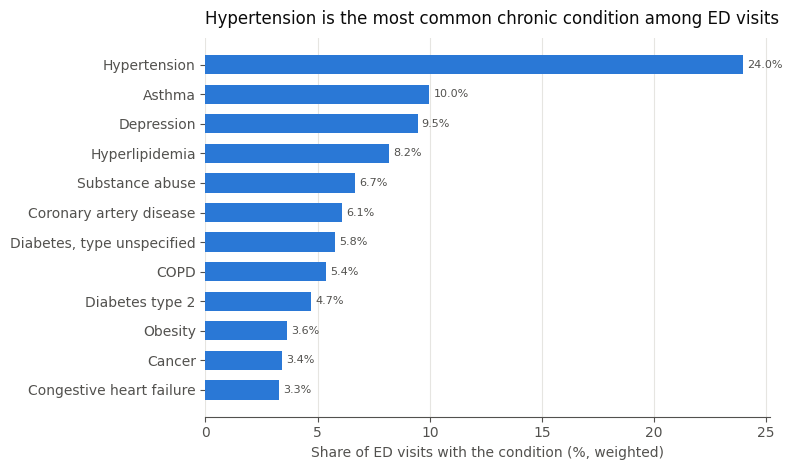

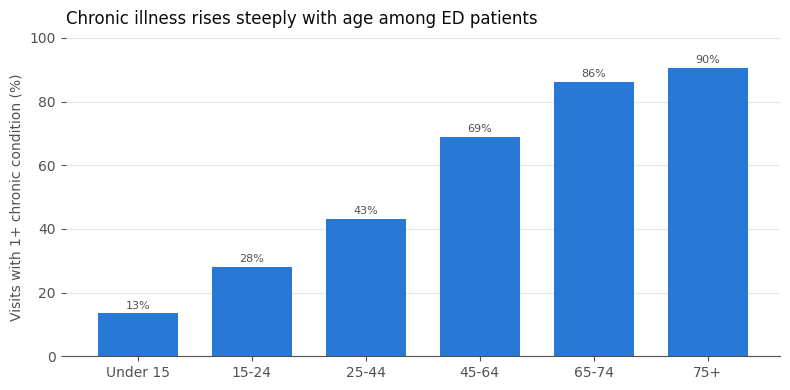

In [8]:
# =============================================================================
# QUESTION 6 - Chronic conditions
# =============================================================================
# The 2015 form has 22 "Does the patient have...?" checkboxes (codebook p.50-51).
# TOTCHRON = how many were checked; -9 = the whole section was left blank.
CHRONIC = {"HTN": "Hypertension", "HYPLIPID": "Hyperlipidemia", "DIABTYP2": "Diabetes type 2",
           "DEPRN": "Depression", "ASTHMA": "Asthma", "OBESITY": "Obesity", "COPD": "COPD",
           "CAD": "Coronary artery disease", "SUBSTAB": "Substance abuse",
           "ETOHAB": "Alcohol misuse", "CANCER": "Cancer", "CHF": "Congestive heart failure",
           "CKD": "Chronic kidney disease", "CEBVD": "Stroke/TIA history",
           "ALZHD": "Alzheimer's/dementia", "DIABTYP0": "Diabetes, type unspecified",
           "DIABTYP1": "Diabetes type 1", "OSA": "Obstructive sleep apnea",
           "HPE": "Pulmonary embolism/DVT history", "ESRD": "End-stage renal disease",
           "OSTPRSIS": "Osteoporosis", "EDHIV": "HIV/AIDS"}

totchron = valid("TOTCHRON")          # -9 (section blank) -> NaN
answered = totchron.notna()           # visits where the section was filled in
print(f"Chronic-condition section answered: {answered.sum():,} of {len(df):,} visits "
      f"({100 * (~answered).mean():.1f}% blank, excluded from this question)")

# Sanity check: TOTCHRON should equal the number of boxes ticked
boxes_ticked = (df[list(CHRONIC)] == 1).sum(axis=1)
print(f"TOTCHRON equals the number of ticked boxes on "
      f"{100 * (boxes_ticked[answered] == totchron[answered]).mean():.1f}% of answered visits")

# ---- (a) Share of visits with at least one chronic condition ----------------
print("\n" + "=" * 70 + "\nQ6(a) VISITS WITH AT LEAST ONE CHRONIC CONDITION\n" + "=" * 70)
Wa = W[answered]                               # weights for answered visits only
has_any = totchron[answered] >= 1
print(f"At least one chronic condition: unweighted {100 * has_any.mean():.1f}% | "
      f"weighted {100 * Wa[has_any].sum() / Wa.sum():.1f}%")
print(f"No chronic condition (weighted): {100 * Wa[~has_any].sum() / Wa.sum():.1f}%  "
      f"(codebook p.4 reports 51.7%)")

# How many conditions per visit (0, 1, 2, 3+)
n_group = pd.cut(totchron, bins=[-1, 0, 1, 2, 99], labels=[0, 1, 2, 3]).astype(float)
print("\nNumber of chronic conditions per visit:")
show(share_table(n_group, {0: "0 conditions", 1: "1", 2: "2", 3: "3 or more"}))
print(f"Mean conditions per visit (weighted): {w_mean(totchron):.2f}")

# ---- (b) Most prevalent conditions -------------------------------------------
print("\n" + "=" * 70 + "\nQ6(b) PREVALENCE OF EACH CONDITION (answered visits)\n" + "=" * 70)
flags = df.loc[answered, list(CHRONIC)] == 1
prevalence = pd.DataFrame({
    "% unweighted": 100 * flags.mean(),
    "% weighted": 100 * flags.mul(Wa, axis=0).sum() / Wa.sum(),
}).rename(index=CHRONIC).sort_values("% weighted", ascending=False)
show(prevalence.round(2))
print(f"\nMost prevalent: {prevalence.index[0]} ({prevalence.iloc[0, 1]:.1f}% of visits)")
print("The four named in the assignment (weighted %):",
      {CHRONIC[c]: round(float(prevalence.loc[CHRONIC[c], "% weighted"]), 2)
       for c in ["HTN", "DIABTYP2", "OBESITY", "DEPRN"]})

# Diabetes is split across 3 checkboxes (type 1, type 2, type unspecified).
# Counting a visit once if ANY of the three is ticked:
any_diabetes = (df.loc[answered, ["DIABTYP1", "DIABTYP2", "DIABTYP0"]] == 1).any(axis=1)
print(f"Any diabetes (type 1, 2 or unspecified): unweighted {100 * any_diabetes.mean():.2f}% | "
      f"weighted {100 * Wa[any_diabetes].sum() / Wa.sum():.2f}% of visits")

# Chronic burden rises steeply with age
chron_by_age = pd.DataFrame({
    "% with 1+ condition": 100 * (Wa[has_any].groupby(df.loc[answered, "AGER"][has_any]).sum()
                                  / Wa.groupby(df.loc[answered, "AGER"]).sum()),
    "mean # conditions": (totchron[answered] * Wa).groupby(df.loc[answered, "AGER"]).sum()
                         / Wa.groupby(df.loc[answered, "AGER"]).sum(),
})
chron_by_age.index = [AGE_GROUPS[a] for a in chron_by_age.index]
print("\nChronic conditions by age group (weighted):")
show(chron_by_age.round(2))

# ---- Chart 1: top 12 conditions, ordered by prevalence ----------------------
top = prevalence["% weighted"].head(12).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(top.index, top.values, color=BLUE, height=0.65)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8, color=INK_SOFT)
style_axes(ax, "Hypertension is the most common chronic condition among ED visits",
           xlabel="Share of ED visits with the condition (%, weighted)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID, linewidth=0.8)
save_fig(fig, "q6_chronic_condition_prevalence")

# ---- Chart 2: share with any chronic condition, by age ----------------------
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(chron_by_age.index, chron_by_age["% with 1+ condition"], color=BLUE, width=0.7)
ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=8, color=INK_SOFT)
ax.set_ylim(0, 100)
style_axes(ax, "Chronic illness rises steeply with age among ED patients",
           ylabel="Visits with 1+ chronic condition (%)")
save_fig(fig, "q6_chronic_by_age")

## QUESTION 7 - Injuries and intentionality

Q7(a) INJURY / OVERDOSE / ADVERSE-EFFECT VISITS
                                sample rows  % unweighted  weighted visits (M)  % weighted
Blank                                    44          0.21                 0.30        0.22
Unknown                                 775          3.68                 5.12        3.74
Injury/trauma                          6271         29.78                40.38       29.49
Overdose/poisoning                      279          1.32                 1.89        1.38
Adverse effect of medical care          486          2.31                 3.04        2.22
Not injury-related                    13153         62.45                85.82       62.67
Questionable injury status               53          0.25                 0.40        0.29

Injury, overdose or adverse effect: unweighted 33.4% | weighted 33.1% of ALL visits
   as a share of visits with a clear yes/no answer: 34.6% (weighted)

Q7(b) INTENT, AMONG INJURY/OVERDOSE/ADVERSE-EFFECT VISITS
           

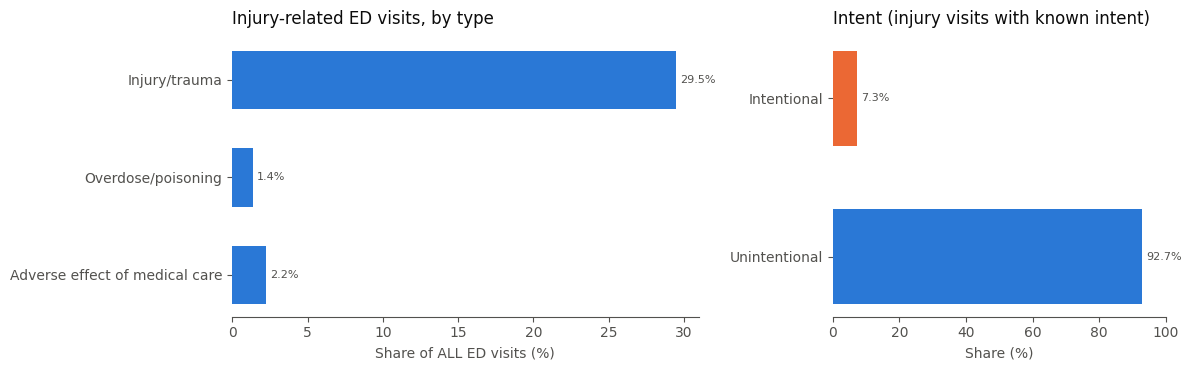

In [9]:
# =============================================================================
# QUESTION 7 - Injuries and intentionality
# =============================================================================
INJ_LABELS = {-9: "Blank", -8: "Unknown", 1: "Injury/trauma", 2: "Overdose/poisoning",
              3: "Adverse effect of medical care", 4: "Not injury-related",
              5: "Questionable injury status"}
INTENT_LABELS = {-9: "Blank", -8: "Unknown / intent unclear", 1: "Intentional",
                 2: "Unintentional", 4: "Questionable injury status"}
inj = pd.to_numeric(df["INJPOISAD"], errors="coerce")
intent = pd.to_numeric(df["INTENT15"], errors="coerce")

# ---- (a) Share of visits related to injury, overdose or adverse effects -----
print("=" * 70 + "\nQ7(a) INJURY / OVERDOSE / ADVERSE-EFFECT VISITS\n" + "=" * 70)
show(share_table(inj, INJ_LABELS))
is_inj = inj.isin([1, 2, 3])                        # the three "Yes" answers
known_inj = inj.isin([1, 2, 3, 4])                  # drops blank/unknown/questionable
print(f"\nInjury, overdose or adverse effect: unweighted {100 * is_inj.mean():.1f}% | "
      f"weighted {100 * W[is_inj].sum() / W.sum():.1f}% of ALL visits")
print(f"   as a share of visits with a clear yes/no answer: "
      f"{100 * W[is_inj].sum() / W[known_inj].sum():.1f}% (weighted)")

# ---- (b) Intentional vs unintentional, among those visits --------------------
# Note: intent is only asked for injuries and overdoses - it is always blank for
# adverse effects of medical care (see the intent-by-type table below).
print("\n" + "=" * 70 + "\nQ7(b) INTENT, AMONG INJURY/OVERDOSE/ADVERSE-EFFECT VISITS\n" + "=" * 70)
show(share_table(intent[is_inj], INTENT_LABELS, w=W[is_inj]))
known_intent = is_inj & intent.isin([1, 2])
Wk = W[known_intent]
pct_intentional = 100 * Wk[intent[known_intent] == 1].sum() / Wk.sum()
print(f"\nAmong visits with KNOWN intent: intentional {pct_intentional:.1f}% | "
      f"unintentional {100 - pct_intentional:.1f}% (weighted)")

# Intent by injury type (weighted %, each row sums to 100)
intent_by_type = pd.crosstab(inj[is_inj].map(INJ_LABELS), intent[is_inj].map(INTENT_LABELS),
                             values=W[is_inj], aggfunc="sum", normalize="index") * 100
print("\nIntent by injury type (weighted %, rows sum to 100):")
show(intent_by_type.round(1))

# Who has intentional injuries? Intentional share (known intent) by age and sex
SEX = {1: "Female", 2: "Male"}
intent_by_group = pd.DataFrame({
    "by age: % intentional": (Wk[intent[known_intent] == 1].groupby(df["AGER"][known_intent]
                              [intent[known_intent] == 1]).sum()
                              / Wk.groupby(df["AGER"][known_intent]).sum() * 100)
}).rename(index=AGE_GROUPS)
print("\n% intentional among injury visits with known intent, by age (weighted):")
show(intent_by_group.round(1))
intent_by_sex = (Wk[intent[known_intent] == 1].groupby(df["SEX"][known_intent]
                 [intent[known_intent] == 1]).sum()
                 / Wk.groupby(df["SEX"][known_intent]).sum() * 100).rename(index=SEX)
print("\n% intentional, by sex (weighted):")
show(intent_by_sex.round(1).to_frame("% intentional"))

# ---- Chart: injury types (share of all visits) + intent split ---------------
types = pd.Series({INJ_LABELS[c]: 100 * W[inj == c].sum() / W.sum() for c in [1, 2, 3]})
intent_known = pd.Series({"Unintentional": 100 - pct_intentional,
                          "Intentional": pct_intentional})
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.4, 1]})
b = axes[0].barh(types.index[::-1], types.values[::-1], color=BLUE, height=0.6)
axes[0].bar_label(b, fmt="%.1f%%", padding=3, fontsize=8, color=INK_SOFT)
style_axes(axes[0], "Injury-related ED visits, by type", xlabel="Share of ALL ED visits (%)")
axes[0].grid(axis="y", visible=False)
b = axes[1].barh(intent_known.index, intent_known.values, color=[BLUE, ORANGE], height=0.6)
axes[1].bar_label(b, fmt="%.1f%%", padding=3, fontsize=8, color=INK_SOFT)
axes[1].set_xlim(0, 100)
style_axes(axes[1], "Intent (injury visits with known intent)", xlabel="Share (%)")
axes[1].grid(axis="y", visible=False)
save_fig(fig, "q7_injuries_and_intent")

## QUESTION 8 - Diagnostic services (imaging and blood tests)

Diagnostic-services section blank (DIAGSCRN = 2): 1.1% of visits (weighted) - their test boxes are all 0, so rates below are per ALL visits, as the question asks

Q8(a) IMAGING (share of ALL visits)
               % unweighted  % weighted
Any imaging           45.54       47.05
X-ray                 32.51       33.65
CT scan               15.75       16.50
Ultrasound             4.43        4.38
MRI                    0.80        0.74
Other imaging          0.93        0.90

Any imaging: injury visits 54.0% vs non-injury visits 44.4% (weighted)
Any imaging, by age group (weighted %):
          % with any imaging
Under 15                29.4
15-24                   40.0
25-44                   44.3
45-64                   56.5
65-74                   65.9
75+                     70.3

Q8(b) BLOOD TESTS
Visits with at least one blood test: unweighted 41.5% | weighted 42.4%

Among visits WITH a blood test, % that included each test (weighted):
                               % of blood-tes

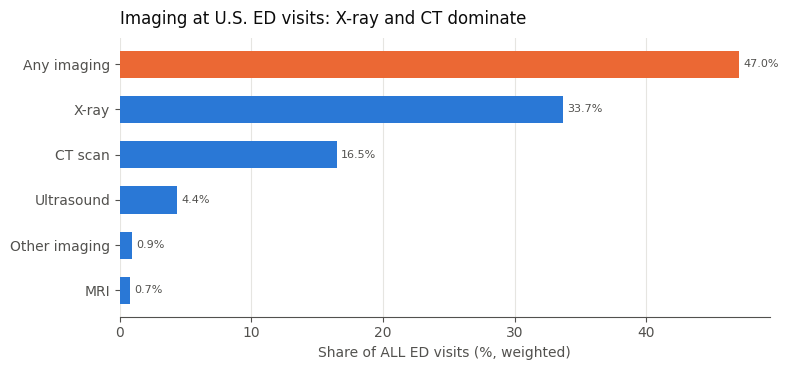

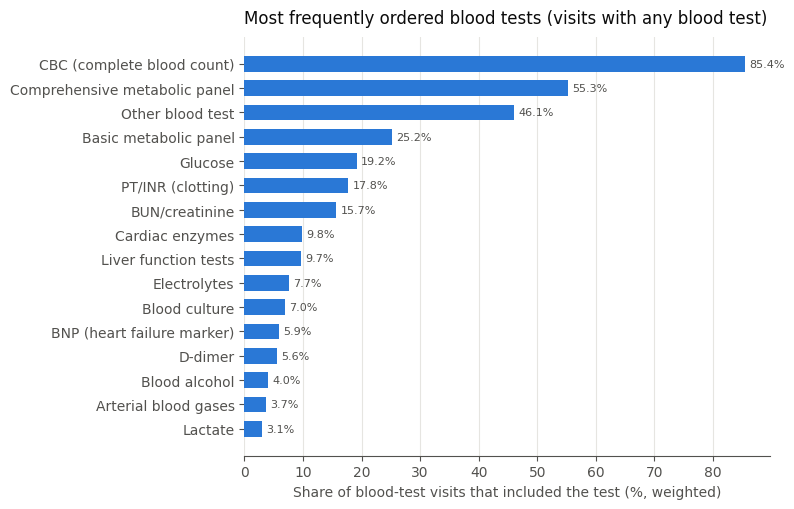

In [10]:
# =============================================================================
# QUESTION 8 - Diagnostic services (imaging and blood tests)
# =============================================================================
# Each test is a 0/1 checkbox (1 = ordered or provided at this visit).
# DIAGSCRN: 0 = no diagnostic services, 1 = yes, 2 = whole section left blank.
diag = pd.to_numeric(df["DIAGSCRN"], errors="coerce")
print(f"Diagnostic-services section blank (DIAGSCRN = 2): "
      f"{100 * W[diag == 2].sum() / W.sum():.1f}% of visits (weighted) "
      f"- their test boxes are all 0, so rates below are per ALL visits, as the question asks")

def pct_of(mask, base=None):
    """Weighted % of visits where `mask` is True, within the `base` group (default all)."""
    base = pd.Series(True, index=df.index) if base is None else base
    return 100 * W[mask & base].sum() / W[base].sum()

# ---- (a) Imaging ---------------------------------------------------------------
print("\n" + "=" * 70 + "\nQ8(a) IMAGING (share of ALL visits)\n" + "=" * 70)
IMAGING = {"ANYIMAGE": "Any imaging", "XRAY": "X-ray", "CATSCAN": "CT scan",
           "ULTRASND": "Ultrasound", "MRI": "MRI", "OTHIMAGE": "Other imaging"}
imaging = pd.DataFrame({
    "% unweighted": {IMAGING[c]: 100 * (df[c] == 1).mean() for c in IMAGING},
    "% weighted": {IMAGING[c]: pct_of(df[c] == 1) for c in IMAGING},
})
show(imaging.round(2))

# Imaging use depends strongly on why the patient came: injury vs not
img = df["ANYIMAGE"] == 1
print(f"\nAny imaging: injury visits {pct_of(img, is_inj):.1f}% vs "
      f"non-injury visits {pct_of(img, inj == 4):.1f}% (weighted)")
img_by_age = pd.Series({AGE_GROUPS[a]: pct_of(img, df["AGER"] == a) for a in AGE_GROUPS})
print("Any imaging, by age group (weighted %):")
show(img_by_age.round(1).to_frame("% with any imaging"))

# ---- (b) Blood tests -------------------------------------------------------------
print("\n" + "=" * 70 + "\nQ8(b) BLOOD TESTS\n" + "=" * 70)
BLOOD = {"CBC": "CBC (complete blood count)", "BMP": "Basic metabolic panel",
         "CMP": "Comprehensive metabolic panel", "GLUCOSE": "Glucose",
         "BUNCREAT": "BUN/creatinine", "ELECTROL": "Electrolytes",
         "CARDENZ": "Cardiac enzymes", "LFT": "Liver function tests",
         "PTTINR": "PT/INR (clotting)", "LACTATE": "Lactate", "BLOODCX": "Blood culture",
         "BNP": "BNP (heart failure marker)", "DDIMER": "D-dimer",
         "BAC": "Blood alcohol", "ABG": "Arterial blood gases", "OTHERBLD": "Other blood test"}
any_blood = (df[list(BLOOD)] == 1).any(axis=1)
print(f"Visits with at least one blood test: unweighted {100 * any_blood.mean():.1f}% | "
      f"weighted {pct_of(any_blood):.1f}%")

blood = pd.DataFrame({
    "% of blood-test visits": {BLOOD[c]: pct_of(df[c] == 1, any_blood) for c in BLOOD},
    "% of ALL visits": {BLOOD[c]: pct_of(df[c] == 1) for c in BLOOD},
}).sort_values("% of blood-test visits", ascending=False)
print("\nAmong visits WITH a blood test, % that included each test (weighted):")
show(blood.round(2))
n_tests = (df.loc[any_blood, list(BLOOD)] == 1).sum(axis=1)
print(f"\nAverage number of different blood tests per blood-test visit (weighted): "
      f"{w_mean(n_tests, W[any_blood]):.2f}")

# Unit test against the codebook (p.4, % of ALL visits)
print("\nCheck vs codebook p.4 (% of all visits):")
for c, pct in {"BUNCREAT": 6.7, "ELECTROL": 3.3, "GLUCOSE": 8.1}.items():
    ours = pct_of(df[c] == 1)
    print(f"   {BLOOD[c]:<16} ours {ours:5.2f}% | codebook {pct}% -> "
          f"{'MATCH' if abs(ours - pct) < 0.1 else 'DIFFERENT'}")

# ---- Chart 1: imaging types ----------------------------------------------------
chart = imaging["% weighted"].sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(chart.index, chart.values,
               color=[ORANGE if i == "Any imaging" else BLUE for i in chart.index], height=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8, color=INK_SOFT)
style_axes(ax, "Imaging at U.S. ED visits: X-ray and CT dominate",
           xlabel="Share of ALL ED visits (%, weighted)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID, linewidth=0.8)
save_fig(fig, "q8_imaging")

# ---- Chart 2: blood tests among blood-test visits ------------------------------
chart = blood["% of blood-test visits"].sort_values()
fig, ax = plt.subplots(figsize=(8, 5.2))
bars = ax.barh(chart.index, chart.values, color=BLUE, height=0.65)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8, color=INK_SOFT)
style_axes(ax, "Most frequently ordered blood tests (visits with any blood test)",
           xlabel="Share of blood-test visits that included the test (%, weighted)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID, linewidth=0.8)
save_fig(fig, "q8_blood_tests")

## QUESTION 9 - Medications (NUMMED and MED1-MED30)

NUMMED equals the number of filled MED1-MED30 slots on 100.0% of visits

Q9(a) MEDICATIONS PER VISIT
                              unweighted  weighted
Mean medications per visit          2.54      2.49
Median medications per visit        2.00      2.00
(30 is the form's maximum - a handful of visits hit that cap, so the mean is a slight underestimate for the most complex visits)
Weighted mean given in the ED: 1.62 | prescribed at discharge: 1.08

Estimated U.S. drug mentions in 2015: 340,550,921 (codebook p.118: 340,550,921 -> MATCH)

Q9(b) VISITS BY NUMBER OF MEDICATIONS
                       sample rows  % unweighted  weighted visits (M)  % weighted
No medications                4281         20.33                28.68       20.94
1-2 medications               8819         41.87                57.39       41.91
3 or more medications         7961         37.80                50.87       37.15

Check vs codebook p.117 (weighted %):
   No medications         ours  20.94 | codebook 20.9

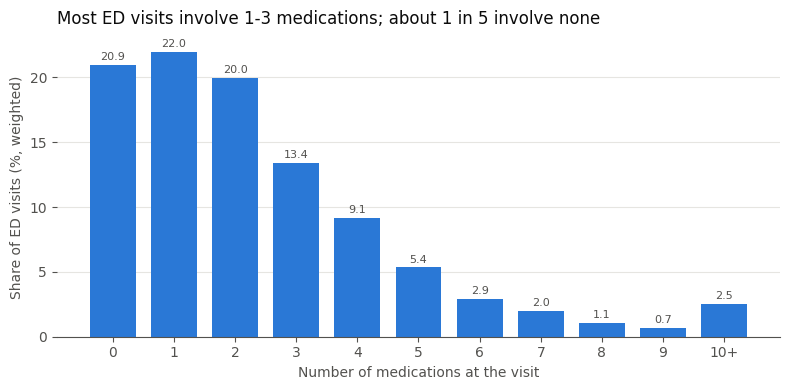

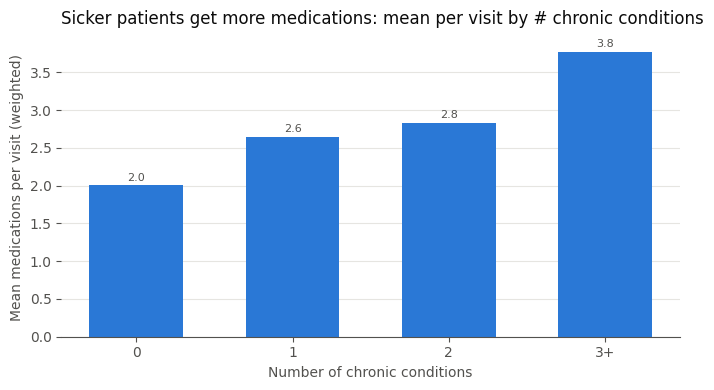

In [11]:
# =============================================================================
# QUESTION 9 - Medications (NUMMED and MED1-MED30)
# =============================================================================
# NUMMED = number of medications coded for the visit (0-30), given in the ED
# and/or prescribed at discharge. MED1..MED30 hold the drug codes; an empty
# slot is -9 ("no entry made"). NUMMED has no missing codes (see Q1).
nummed = pd.to_numeric(df["NUMMED"], errors="coerce")

# Consistency check: NUMMED should equal the number of filled MED slots
med_cols = [f"MED{i}" for i in range(1, 31)]
filled = (df[med_cols].apply(pd.to_numeric, errors="coerce") > 0).sum(axis=1)
print(f"NUMMED equals the number of filled MED1-MED30 slots on "
      f"{100 * (filled == nummed).mean():.1f}% of visits")

# ---- (a) Mean and median medications per visit ------------------------------
print("\n" + "=" * 70 + "\nQ9(a) MEDICATIONS PER VISIT\n" + "=" * 70)
q9 = pd.DataFrame({
    "unweighted": [nummed.mean(), nummed.median()],
    "weighted": [w_mean(nummed), w_median(nummed)],
}, index=["Mean medications per visit", "Median medications per visit"])
show(q9.round(2))
print("(30 is the form's maximum - a handful of visits hit that cap, so the mean is a slight "
      "underestimate for the most complex visits)")

# Given in the ED vs prescribed at discharge (0 includes 'none listed/unknown')
numgiv = pd.to_numeric(df["NUMGIV"], errors="coerce")
numdis = pd.to_numeric(df["NUMDIS"], errors="coerce")
print(f"Weighted mean given in the ED: {w_mean(numgiv):.2f} | "
      f"prescribed at discharge: {w_mean(numdis):.2f}")

# Total drug mentions = sum of PATWT x NUMMED (codebook p.27 "DRUGWT")
mentions = (W * nummed).sum()
print(f"\nEstimated U.S. drug mentions in 2015: {mentions:,.0f} "
      f"(codebook p.118: 340,550,921 -> {'MATCH' if round(mentions) == 340550921 else 'DIFFERENT'})")

# ---- (b) Share of visits with 0, 1-2, 3+ medications ------------------------
print("\n" + "=" * 70 + "\nQ9(b) VISITS BY NUMBER OF MEDICATIONS\n" + "=" * 70)
med_group = pd.cut(nummed, bins=[-1, 0, 2, 99], labels=[0, 1, 2]).astype(float)
med_table = share_table(med_group, {0: "No medications", 1: "1-2 medications",
                                    2: "3 or more medications"})
show(med_table)
print("\nCheck vs codebook p.117 (weighted %):")
for name, pct in {"No medications": 20.943, "1-2 medications": 21.957 + 19.950,
                  "3 or more medications": 100 - 20.943 - 21.957 - 19.950}.items():
    ours = med_table.loc[name, "% weighted"]
    print(f"   {name:<22} ours {ours:6.2f} | codebook {pct:6.3f} -> "
          f"{'MATCH' if abs(ours - pct) < 0.01 else 'DIFFERENT'}")

# Treatment intensity rises with patient complexity (chronic conditions) and age
chron_group = pd.cut(totchron, bins=[-1, 0, 1, 2, 99], labels=["0", "1", "2", "3+"])
meds_by_chron = pd.Series({g: w_mean(nummed[chron_group == g], W[chron_group == g])
                           for g in ["0", "1", "2", "3+"]})
meds_by_age = pd.Series({AGE_GROUPS[a]: w_mean(nummed[df["AGER"] == a], W[df["AGER"] == a])
                         for a in AGE_GROUPS})
three_plus_by_age = pd.Series({AGE_GROUPS[a]: pct_of(nummed >= 3, df["AGER"] == a)
                               for a in AGE_GROUPS})
print("\nMean medications per visit, by number of chronic conditions (weighted):")
show(meds_by_chron.round(2).to_frame("mean # medications"))
print("\nBy age group (weighted):")
show(pd.DataFrame({"mean # medications": meds_by_age,
                   "% with 3+ medications": three_plus_by_age}).round(2))

# ---- Chart 1: distribution of medications per visit (0..10+) ----------------
dist = 100 * W.groupby(nummed.clip(upper=10)).sum() / W.sum()
dist.index = [str(int(i)) if i < 10 else "10+" for i in dist.index]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dist.index, dist.values, color=BLUE, width=0.75)
ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8, color=INK_SOFT)
style_axes(ax, "Most ED visits involve 1-3 medications; about 1 in 5 involve none",
           xlabel="Number of medications at the visit", ylabel="Share of ED visits (%, weighted)")
save_fig(fig, "q9_medications_per_visit")

# ---- Chart 2: medications rise with chronic-condition burden ----------------
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(meds_by_chron.index, meds_by_chron.values, color=BLUE, width=0.6)
ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8, color=INK_SOFT)
style_axes(ax, "Sicker patients get more medications: mean per visit by # chronic conditions",
           xlabel="Number of chronic conditions", ylabel="Mean medications per visit (weighted)")
save_fig(fig, "q9_meds_by_chronic_conditions")

## QUESTION 10 - Correlations

Sample counts behind the rare outcomes:
   died in ED: 28 rows | dead on arrival: 7 rows | died in hospital: 40 of 1752 admitted with known status
   weighted rates: died in ED 0.10% | DOA 0.04% | admitted 9.0% | in-hospital death among admitted 2.6%

Weighted-correlation function passes its unit test.

Q10 - 20 STRONGEST WEIGHTED CORRELATIONS
                                                                 r
age                           Medicare                       0.610
                              # chronic conditions           0.547
# chronic conditions          Medicare                       0.444
age                           Medicaid                      -0.389
# blood tests                 admitted                       0.375
# chronic conditions          # blood tests                  0.374
age                           # blood tests                  0.368
Medicaid                      Medicare                      -0.365
triage (1=most urgent)        # blood tests        

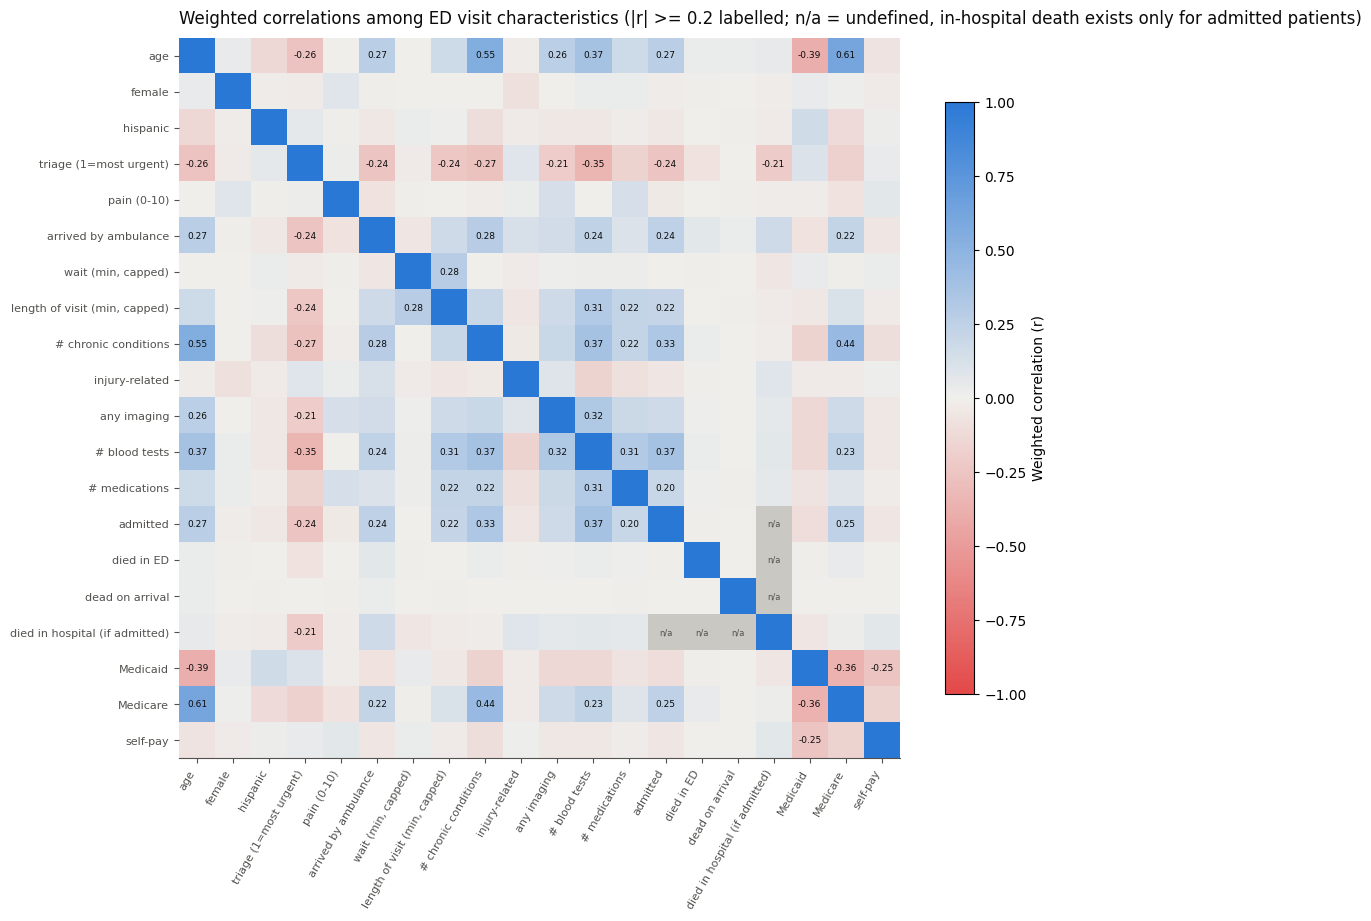

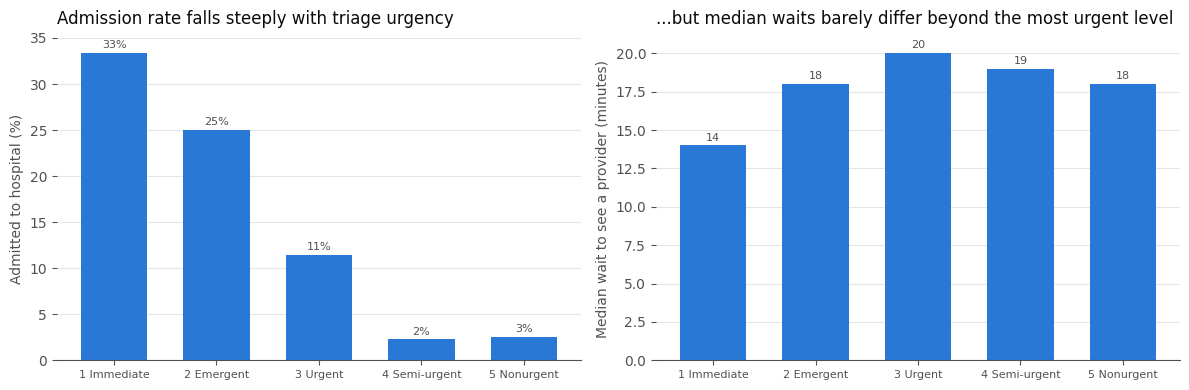

In [12]:
# =============================================================================
# QUESTION 10 - Correlations
# =============================================================================
# One tidy table of cleaned variables: yes/no items become 0/1, every missing
# code becomes NaN, so each correlation uses only rows with real answers.
# Triage (IMMEDR): 1 = Immediate ... 5 = Nonurgent. Codes 0/7 (no triage) dropped.
# So a NEGATIVE correlation with triage level means "more of it for more urgent patients".
triage = pd.to_numeric(df["IMMEDR"], errors="coerce")
hdstat = pd.to_numeric(df["HDSTAT"], errors="coerce")
ems = pd.to_numeric(df["ARREMS"], errors="coerce")
admitted = ((df["ADMITHOS"] == 1) | (df["OBSHOS"] == 1)).astype(float)   # admitted to hospital
pain = valid("PAINSCALE")

cv = pd.DataFrame({
    "age": age,
    "female": (df["SEX"] == 1).astype(float),
    "hispanic": (df["ETHIM"] == 1).astype(float),
    "triage (1=most urgent)": triage.where(triage.between(1, 5)),
    "pain (0-10)": pain.where(pain.between(0, 10)),
    "arrived by ambulance": ems.map({1: 1.0, 2: 0.0}),
    "wait (min, capped)": wait_win,
    "length of visit (min, capped)": lov_win,
    "# chronic conditions": totchron,
    "injury-related": inj.map({1: 1.0, 2: 1.0, 3: 1.0, 4: 0.0}),
    "any imaging": (df["ANYIMAGE"] == 1).astype(float),
    "# blood tests": (df[list(BLOOD)] == 1).sum(axis=1).astype(float),
    "# medications": nummed.astype(float),
    "admitted": admitted,
    "died in ED": (df["DIEDED"] == 1).astype(float),
    "dead on arrival": (df["DOA"] == 1).astype(float),
    "died in hospital (if admitted)": hdstat.map({1: 0.0, 2: 1.0}),   # HDSTAT only for admitted
    "Medicaid": pay.map(lambda c: 1.0 if c == 3 else 0.0).where(known),
    "Medicare": pay.map(lambda c: 1.0 if c == 2 else 0.0).where(known),
    "self-pay": pay.map(lambda c: 1.0 if c == 5 else 0.0).where(known),
})

# Rare outcomes: how many sampled visits are behind them? (small counts = noisy)
print("Sample counts behind the rare outcomes:")
print(f"   died in ED: {int(cv['died in ED'].sum())} rows | dead on arrival: "
      f"{int(cv['dead on arrival'].sum())} rows | died in hospital: "
      f"{int((hdstat == 2).sum())} of {int(hdstat.isin([1, 2]).sum())} admitted with known status")
print(f"   weighted rates: died in ED {100 * w_mean(cv['died in ED']):.2f}% | DOA "
      f"{100 * w_mean(cv['dead on arrival']):.2f}% | admitted {100 * w_mean(admitted):.1f}% | "
      f"in-hospital death among admitted {100 * w_mean(cv['died in hospital (if admitted)']):.1f}%")

def w_corr(x, y, w=W):
    """Weighted Pearson correlation, using rows where both x and y are present."""
    keep = x.notna() & y.notna()
    x, y, w = x[keep].astype(float), y[keep].astype(float), w[keep]
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cov = np.average((x - mx) * (y - my), weights=w)
    vx, vy = np.average((x - mx) ** 2, weights=w), np.average((y - my) ** 2, weights=w)
    return cov / np.sqrt(vx * vy) if vx > 0 and vy > 0 else np.nan

# Unit test (Class 2): equal weights must reproduce pandas' ordinary correlation
t = cv[["age", "# medications"]].dropna()
assert abs(w_corr(t.iloc[:, 0], t.iloc[:, 1], pd.Series(1.0, index=t.index))
           - t.iloc[:, 0].corr(t.iloc[:, 1])) < 1e-10
print("\nWeighted-correlation function passes its unit test.")

# ---- Weighted correlation matrix -------------------------------------------------
names = list(cv.columns)
corr = pd.DataFrame(np.nan, index=names, columns=names)
for i, a in enumerate(names):
    for b in names[i:]:
        corr.loc[a, b] = corr.loc[b, a] = w_corr(cv[a], cv[b])
# Undefined pairs (NaN): "died in hospital" exists only for admitted patients, so it
# cannot vary together with "admitted" (always 1 there) or with ED deaths/DOA.

# Strongest relationships (upper triangle only, so each pair appears once)
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
top = upper.reindex(upper.abs().sort_values(ascending=False).index).head(20)
print("\n" + "=" * 70 + "\nQ10 - 20 STRONGEST WEIGHTED CORRELATIONS\n" + "=" * 70)
show(top.round(3).to_frame("r"))

print("\nCorrelations with the outcome variables (weighted r):")
outcome_cols = ["admitted", "died in ED", "dead on arrival", "died in hospital (if admitted)",
                "length of visit (min, capped)"]
show(corr[outcome_cols].drop(index=outcome_cols).round(2)
     .rename(columns={"died in hospital (if admitted)": "died in hosp.",
                      "length of visit (min, capped)": "LOV (capped)"}))

# ---- Rates by triage level and age: clearer than r for rare outcomes -------------
def w_group_means(frame, group):
    """Weighted mean of every column within each group, skipping missing values."""
    out = {}
    for c in frame.columns:
        keep = frame[c].notna() & group.notna()
        out[c] = ((frame[c][keep] * W[keep]).groupby(group[keep]).sum()
                  / W[keep].groupby(group[keep]).sum())
    return pd.DataFrame(out)

rate_cols = ["admitted", "died in ED", "dead on arrival", "died in hospital (if admitted)",
             "any imaging", "arrived by ambulance"]
SHORT = {"admitted": "% admit", "died in ED": "% died ED", "dead on arrival": "% DOA",
         "died in hospital (if admitted)": "% died hosp.", "any imaging": "% imaging",
         "arrived by ambulance": "% ambulance"}
TRIAGE_NAMES = {1: "1 Immediate", 2: "2 Emergent", 3: "3 Urgent", 4: "4 Semi-urgent",
                5: "5 Nonurgent"}
by_triage = 100 * w_group_means(cv[rate_cols], cv["triage (1=most urgent)"])
by_triage["median wait"] = [w_median(wait[triage == t], W[triage == t]) for t in by_triage.index]
by_triage["mean meds"] = w_group_means(cv[["# medications"]], cv["triage (1=most urgent)"])
by_triage["rows"] = cv["triage (1=most urgent)"].value_counts()
by_triage.index = [TRIAGE_NAMES[int(t)] for t in by_triage.index]
by_triage = by_triage.rename(columns=SHORT)
print("\nBy triage level (weighted; rates in %, median wait in minutes):")
show(by_triage.round(2))

by_age = (100 * w_group_means(cv[rate_cols], df["AGER"])).rename(columns=SHORT)
by_age.index = [AGE_GROUPS[a] for a in by_age.index]
print("\nBy age group (weighted; rates in %):")
show(by_age.round(2))

# ---- Chart 1: correlation heatmap (Class 5), diverging red-grey-blue ------------
from matplotlib.colors import LinearSegmentedColormap
diverging = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
diverging.set_bad("#c9c8c3")                     # undefined pairs shown in darker grey
fig, ax = plt.subplots(figsize=(11, 9.5))
img = ax.imshow(np.ma.masked_invalid(corr.values), cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):                      # label only the meaningful cells
    for j in range(len(names)):
        r = corr.iloc[i, j]
        if i != j and np.isnan(r):
            ax.text(j, i, "n/a", ha="center", va="center", fontsize=6, color=INK_SOFT)
        elif i != j and abs(r) >= 0.2:
            ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=6.5, color=INK)
style_axes(ax, "Weighted correlations among ED visit characteristics (|r| >= 0.2 labelled; "
               "n/a = undefined, in-hospital death exists only for admitted patients)")
ax.grid(False)
fig.colorbar(img, ax=ax, label="Weighted correlation (r)", shrink=0.75)
save_fig(fig, "q10_correlation_heatmap")

# ---- Chart 2: the triage system at work -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
b = axes[0].bar(by_triage.index, by_triage["% admit"], color=BLUE, width=0.65)
axes[0].bar_label(b, fmt="%.0f%%", padding=2, fontsize=8, color=INK_SOFT)
style_axes(axes[0], "Admission rate falls steeply with triage urgency",
           ylabel="Admitted to hospital (%)")
b = axes[1].bar(by_triage.index, by_triage["median wait"], color=BLUE, width=0.65)
axes[1].bar_label(b, fmt="%.0f", padding=2, fontsize=8, color=INK_SOFT)
style_axes(axes[1], "...but median waits barely differ beyond the most urgent level",
           ylabel="Median wait to see a provider (minutes)")
for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
save_fig(fig, "q10_triage_admission_and_wait")

In [13]:
# ---- Verification: fresh run vs the numbers verified step by step ---------------
expected = {   # name: (value from this run, verified value, allowed rounding tolerance)
    "Q1 rows":                        (df.shape[0], 21061, 0),
    "Q1 columns":                     (df.shape[1], 1031, 0),
    "Q2 weighted visits":             (round(W.sum()), 136943181, 0),
    "Q3 % female (wtd)":              (sex_table.loc["Female", "% weighted"], 55.44, 0.01),
    "Q3 % Hispanic (wtd)":            (eth_table.loc["Hispanic or Latino", "% weighted"], 16.49, 0.01),
    "Q3 median wait (wtd, min)":      (w_median(wait), 18, 0),
    "Q3 mean LOV raw (wtd, min)":     (w_mean(lov), 213.7, 0.05),
    "Q4 busiest hour":                (pct_hour.idxmax(), 18, 0),
    "Q5 % Medicaid, known payer":     (pay_known.loc["Medicaid/CHIP", "% weighted"], 34.91, 0.01),
    "Q6 % with 1+ chronic (wtd)":     (100 * Wa[has_any].sum() / Wa.sum(), 47.6, 0.05),
    "Q6 % hypertension (wtd)":        (prevalence.loc["Hypertension", "% weighted"], 23.97, 0.01),
    "Q6 % any diabetes (wtd)":        (100 * Wa[any_diabetes].sum() / Wa.sum(), 11.06, 0.01),
    "Q7 % injury-related (wtd)":      (100 * W[is_inj].sum() / W.sum(), 33.1, 0.05),
    "Q7 % intentional, known intent": (pct_intentional, 7.3, 0.05),
    "Q8 % any imaging (wtd)":         (imaging.loc["Any imaging", "% weighted"], 47.05, 0.01),
    "Q8 % CBC among blood tests":     (blood.loc["CBC (complete blood count)", "% of blood-test visits"], 85.43, 0.01),
    "Q9 drug mentions":               (round(mentions), 340550921, 0),
    "Q9 % with 3+ meds (wtd)":        (med_table.loc["3 or more medications", "% weighted"], 37.15, 0.01),
    "Q10 % admitted (wtd)":           (100 * w_mean(admitted), 9.0, 0.05),
    "Q10 r(age, Medicare)":           (corr.loc["age", "Medicare"], 0.610, 0.0005),
}
fails = 0
for name, (ours, verified, tol) in expected.items():
    ok = abs(float(ours) - float(verified)) <= tol
    fails += not ok
    print(f"{'PASS' if ok else 'FAIL'}  {name:<32} this run {float(ours):>14,.3f} | verified {verified:,}")

# All 18 charts saved?
charts = ["q2_weight_distribution", "q2_region_unweighted_vs_weighted", "q3_wait_and_length_of_visit",
          "q3_age_groups_unweighted_vs_weighted", "q4_visits_by_weekday", "q4_arrivals_by_hour",
          "q4_weekday_hour_heatmap", "q5_payer_mix", "q5_payer_mix_by_age",
          "q6_chronic_condition_prevalence", "q6_chronic_by_age", "q7_injuries_and_intent",
          "q8_imaging", "q8_blood_tests", "q9_medications_per_visit", "q9_meds_by_chronic_conditions",
          "q10_correlation_heatmap", "q10_triage_admission_and_wait"]
missing = [c for c in charts if not os.path.exists(os.path.join(FIG_DIR, c + ".png"))]
print(f"\nCharts saved: {len(charts) - len(missing)} of {len(charts)}", "| missing:" if missing else "", *missing)
print(f"RESULT: {len(expected) - fails} of {len(expected)} numbers match"
      + ("" if fails == 0 else " - send a screenshot of the FAIL lines"))

PASS  Q1 rows                          this run     21,061.000 | verified 21,061
PASS  Q1 columns                       this run      1,031.000 | verified 1,031
PASS  Q2 weighted visits               this run 136,943,181.000 | verified 136,943,181
PASS  Q3 % female (wtd)                this run         55.440 | verified 55.44
PASS  Q3 % Hispanic (wtd)              this run         16.490 | verified 16.49
PASS  Q3 median wait (wtd, min)        this run         18.000 | verified 18
PASS  Q3 mean LOV raw (wtd, min)       this run        213.709 | verified 213.7
PASS  Q4 busiest hour                  this run         18.000 | verified 18
PASS  Q5 % Medicaid, known payer       this run         34.910 | verified 34.91
PASS  Q6 % with 1+ chronic (wtd)       this run         47.631 | verified 47.6
PASS  Q6 % hypertension (wtd)          this run         23.966 | verified 23.97
PASS  Q6 % any diabetes (wtd)          this run         11.065 | verified 11.06
PASS  Q7 % injury-related (wtd)        